In [16]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [17]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [18]:
query = '''
SELECT
    uid,
    strftime('%w', timestamp) AS weekday,
    strftime('%H', timestamp) AS hour,
    COUNT(*) AS num_commits
FROM
    checker
WHERE
    uid LIKE 'user_%'
GROUP BY
    uid, weekday, hour
'''

In [19]:
df = pd.read_sql(query, conn)

In [20]:
df['weekday'] = df['weekday'].astype(int)
df['hour'] = df['hour'].astype(int)

In [21]:
weekday_pivot = df.pivot_table(index='weekday', columns='uid', values='num_commits', aggfunc='sum', fill_value=0)
hour_pivot = df.pivot_table(index='hour', columns='uid', values='num_commits', aggfunc='sum', fill_value=0)

In [22]:
weekday_order = [1,2,3,4,5,6,0]
weekday_pivot = weekday_pivot.reindex(weekday_order)
weekday_pivot.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

In [23]:
weekday_pivot = weekday_pivot[weekday_pivot.sum(axis=0).sort_values(ascending=False).index]
hour_pivot = hour_pivot[hour_pivot.sum(axis=0).sort_values(ascending=False).index]

In [24]:
def plot_heatmap(data, cmap, figsize=(15,8)):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(data, aspect='auto', cmap=cmap)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.1)
    plt.colorbar(im, cax=cax)
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, rotation=90)
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index)
    fig.set_facecolor('lightgrey')

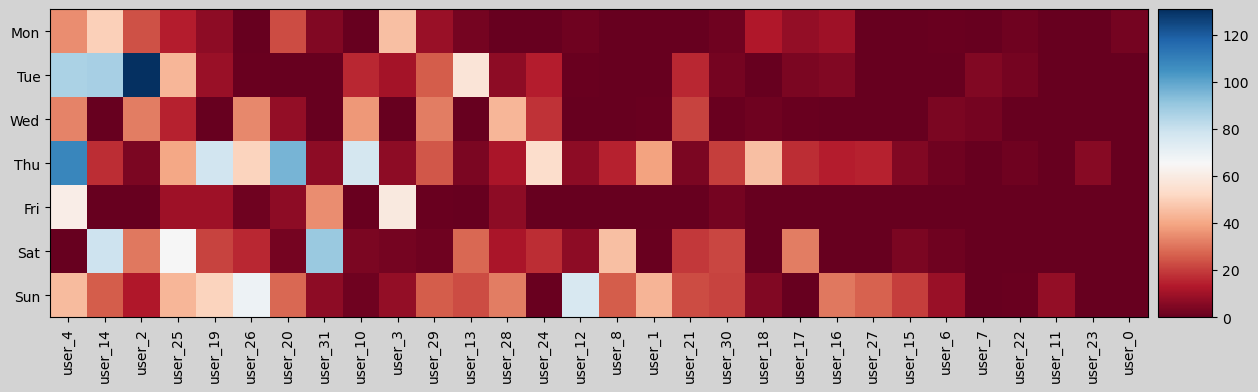

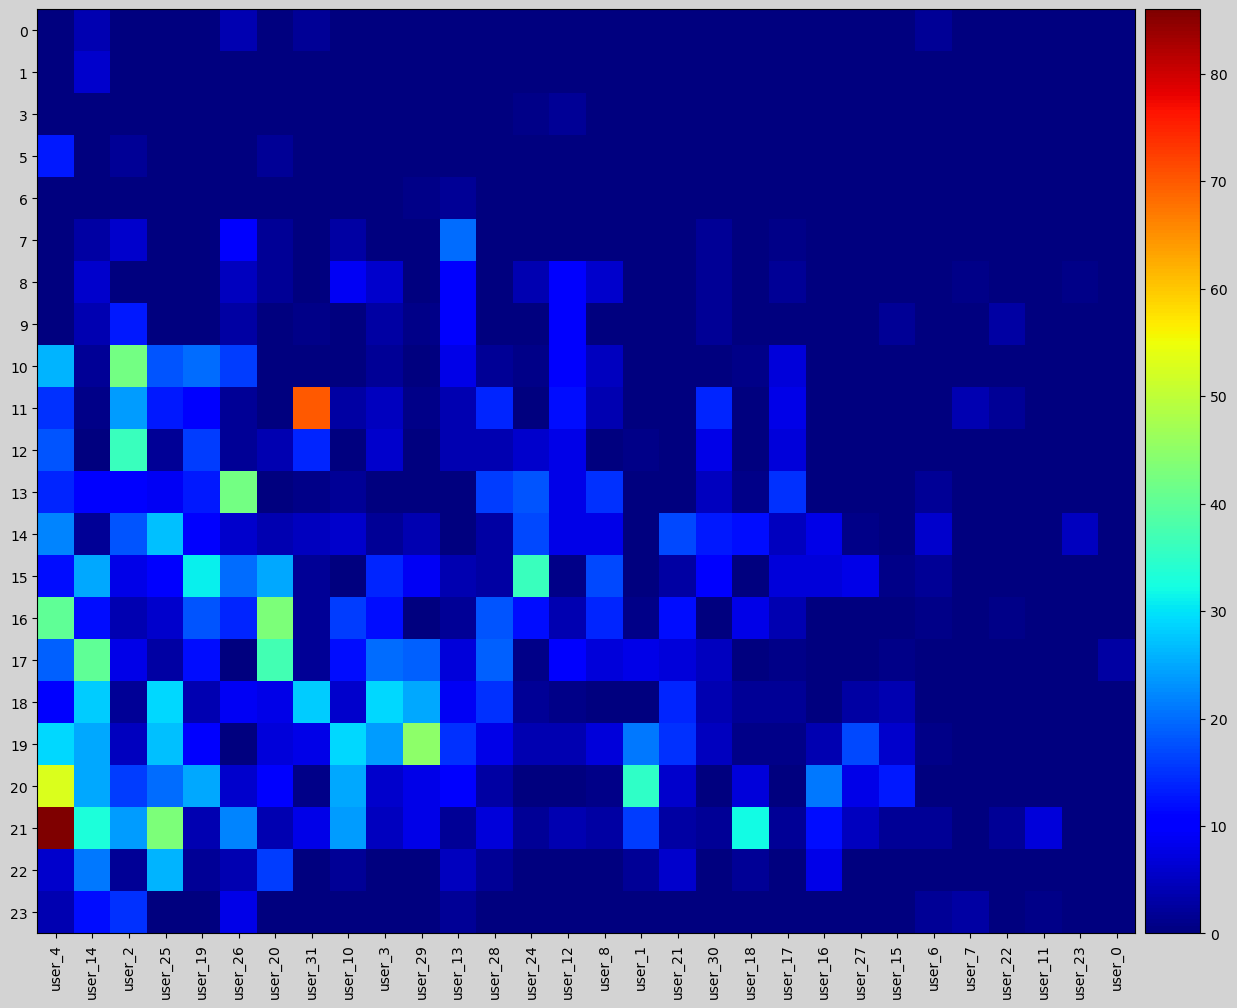

In [25]:
plot_heatmap(weekday_pivot, cmap='RdBu', figsize=(15,4))
plot_heatmap(hour_pivot, cmap='jet', figsize=(15,12))

In [26]:
conn.close()

## Which user has the most commits on Tue?

Answer: user_2.

## Which user has the most commits on Thu?

Answer: user_4.

## On which weekday do the users not like making a lot of commits?

Answer: Fri.

## Which user at which hour made the largest number of commits?

Answer: user_4, 21.